In [1]:
library(Seurat)
library(SeuratData)
library(Connectome)
library(ggplot2)
library(cowplot)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed

‘SeuratObject’ was built with package ‘Matrix’ 1.6.5 but the current
version is 1.7.2; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Installed datasets ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── SeuratData v0.2.1 ──

✔ panc8 3.0.2                                                                                        


─────────────────────────────────────────────────────────────────────────────────────────────────── Key ────────────────────────────────────────────────────────────────────

In [2]:
## figure directory
fig_dir <- '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig_ccc/'

In [3]:
setwd(fig_dir)

In [4]:
## load data
reef <- readRDS('/mnt/smb/Niklas/GLPG_data_temp/250225_GLPG_REEF_subset.rds')

In [5]:
reef

An object of class Seurat 
24500 features across 17102 samples within 1 assay 
Active assay: RNA (24500 features, 0 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: pca, umap

In [6]:
table(Idents(reef))


                          Krt8+ ADI                               Basal 
                                379                                  27 
                      Club/Ciliated                            Ciliated 
                                107                                1138 
Vwa1+/Col15a1+ ectopic capillary EC                      M2 Macrophages 
                               2569                                6612 
                        Eosinophils                        Cd8+ T cells 
                               1819                                4451 

In [7]:
reef[['RNA']]

Assay (v5) data with 24500 features for 17102 cells
First 10 features:
 Xkr4, Gm19938, Rp1, Sox17, Gm37587, Gm6085, Mrpl15, Gm37144, Lypla1,
Tcea1 
Layers:
 counts, data 

In [8]:
## make connectome
connectome.genes <- union(Connectome::ncomms8866_mouse$Ligand.ApprovedSymbol,Connectome::ncomms8866_mouse$Receptor.ApprovedSymbol)
genes <- connectome.genes[connectome.genes %in% rownames(reef)]

In [9]:
#reef <- NormalizeData(reef)
reef <- ScaleData(reef, features = genes)

Centering and scaling data matrix



In [10]:
## convert Assay5 to Assay
counts_data <- reef[['RNA']]$counts
data_data <- reef[['RNA']]$data
scale_data <- reef[['RNA']]$scale.data

## conver extracted data into a Seurat v4-style Assay
new_assay <- CreateAssayObject(counts = counts_data)

## add normalized and scaled data as well
new_assay@data <- data_data
new_assay@scale.data <- scale_data

## add the new assay to Seurat object
reef[['RNA']] <- new_assay

Warning message:
“Assay RNA changing from Assay5 to Assay”


In [11]:
## should now return 'assay' now
class(reef[['RNA']]) 

[1] "Assay"
attr(,"package")
[1] "SeuratObject"

In [12]:
reef

An object of class Seurat 
24500 features across 17102 samples within 1 assay 
Active assay: RNA (24500 features, 0 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [13]:
rownames(reef[['RNA']]) <- as.character(rownames(reef[['RNA']]))

In [14]:
reef.con <- CreateConnectome(reef,
                             assays = 'RNA',
                             slot = 'data', 
                             species = 'mouse',
                             p.values = F,
                             calculate.DOR = F)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
Finished calculating percentage expressing RNA for cluster Krt8+ ADI

Finished calculating percentage expressing RNA for cluster Basal

Finished calculating percentage expressing RNA for cluster Club/Ciliated

Finished calculating percentage expressing RNA for cluster Ciliated

Finished calculating percentage expressing RNA for cluster Vwa1+/Col15a1+ ectopic capillary EC

Finished calculating percentage expressing RNA for cluster M2 Macrophages

Finished calculating percentage expressing RNA for cluster Eosinophils

Finished calculating percentage expressing RNA for cluster Cd8+ T cells


Generating Connectome



  |======================================================================| 100%


Connectome generation complete



Warning message:
“Removed 28800 rows containing non-finite outside the scale range (`stat_density()`).”
Warning message:
“Removed 17216 rows containing non-finite outside the scale range (`stat_density()`).”
Warning message:
“Removed 17216 rows containing non-finite outside the scale range (`stat_density()`).”
Warning message:
“Removed 28800 rows containing non-finite outside the scale range (`stat_density()`).”


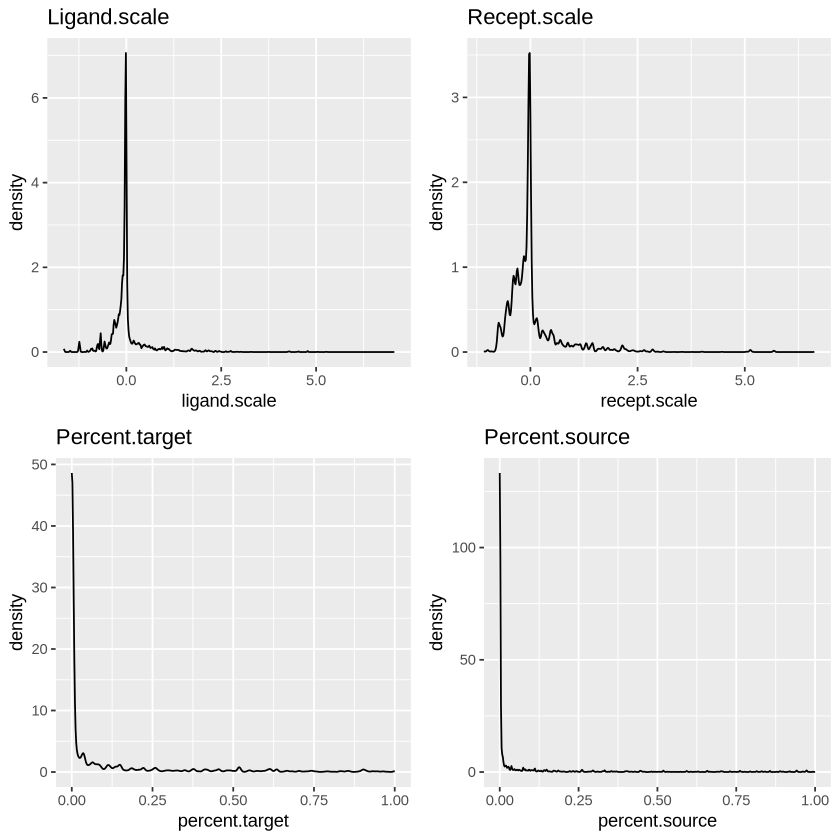

In [15]:
# Change density plot line colors by groups
p1 <- ggplot(reef.con, aes(x=ligand.scale)) + geom_density() + ggtitle('Ligand.scale')
p2 <- ggplot(reef.con, aes(x=recept.scale)) + geom_density() + ggtitle('Recept.scale')
p3 <- ggplot(reef.con, aes(x=percent.target)) + geom_density() + ggtitle('Percent.target')
p4 <- ggplot(reef.con, aes(x=percent.source)) + geom_density() + ggtitle('Percent.source')
plot_grid(p1,p2,p3,p4)

In [16]:
reef.con2 <- FilterConnectome(reef.con,
                              min.pct = 0.1,
                              min.z = 0.25,
                              remove.na = T)


Pre-filter edges:  155008


Post-filter edges:  2176


Connectome filtration completed



Loading required package: igraph


Attaching package: ‘igraph’


The following object is masked from ‘package:tibble’:

    as_data_frame


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following object is masked from ‘package:Seurat’:

    components


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union



Weight attribute is 'weight_sc', recommend also setting min.z = 0 to avoid negative ligand and receptor scores


Pre-filter edges:  2176


Post-filter edges:  2176


Connectome filtration completed

Warning message:
“Removed 82 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”
Warning message:
“Removed 82 rows containing missing values or values outside the sca

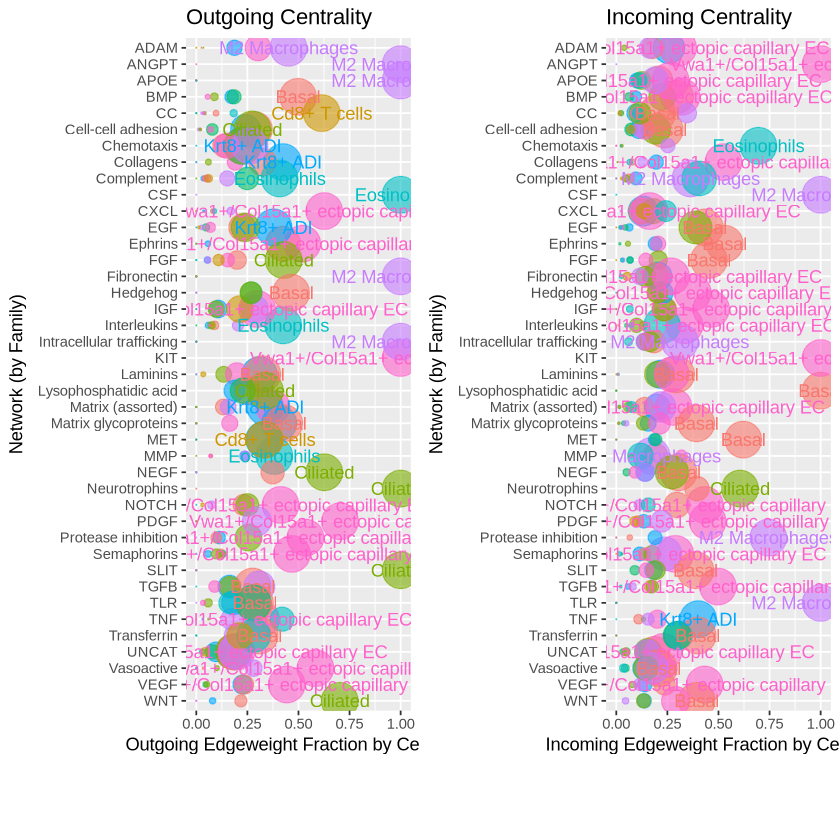

In [17]:
Centrality(reef.con2,
           modes.include = NULL,
           min.z = NULL,
           weight.attribute = 'weight_sc',
           group.by = 'mode')

In [18]:
test <- reef.con2
test <- data.frame(test %>% group_by(vector) %>% top_n(10,weight_sc))

In [19]:
reef_niche <- c('Basal','Ciliated','Krt8+ ADI','Vwa1+/Col15a1+ ectopic capillary EC','Club/Ciliated','M2 Macrophages','Cd8+ T cells')

In [20]:
reef_colors <- c(
    'Eosinophils' = '#D72638',  # Red
    
    'Ciliated' = '#6A0572',  # Deep Purple
    'Club/Ciliated' = '#AB83A1',  # Soft Pink
    'Basal' = '#3C91E6',  # Gold
    'Krt8+ ADI' = '#F4A900',  # Bright Blue

    'Vwa1+/Col15a1+ ectopic capillary EC' = '#F7C59F',   # Warm Beige,
    
    'M2 Macrophages' = '#1B998B',  # Teal
    'Cd8+ T cells' = '#17BEBB'   # Aqua Teal 
)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ lubridate 1.9.4     ✔ stringr   1.5.1
✔ purrr     1.0.4     ✔ tidyr     1.3.1
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%--%()       masks igraph::%--%()
✖ igraph::as_data_frame() masks tibble::as_data_frame(), dplyr::as_data_frame()
✖ purrr::compose()        masks igraph::compose()
✖ tidyr::crossing()       masks igraph::crossing()
✖ dplyr::filter()         masks stats::filter()
✖ dplyr::lag()            masks stats::lag()
✖ purrr::simplify()       masks igraph::simplify()
✖ lubridate::stamp()      masks cowplot::stamp()
ℹ Use the conflicted package (<http://conflicted.r-li

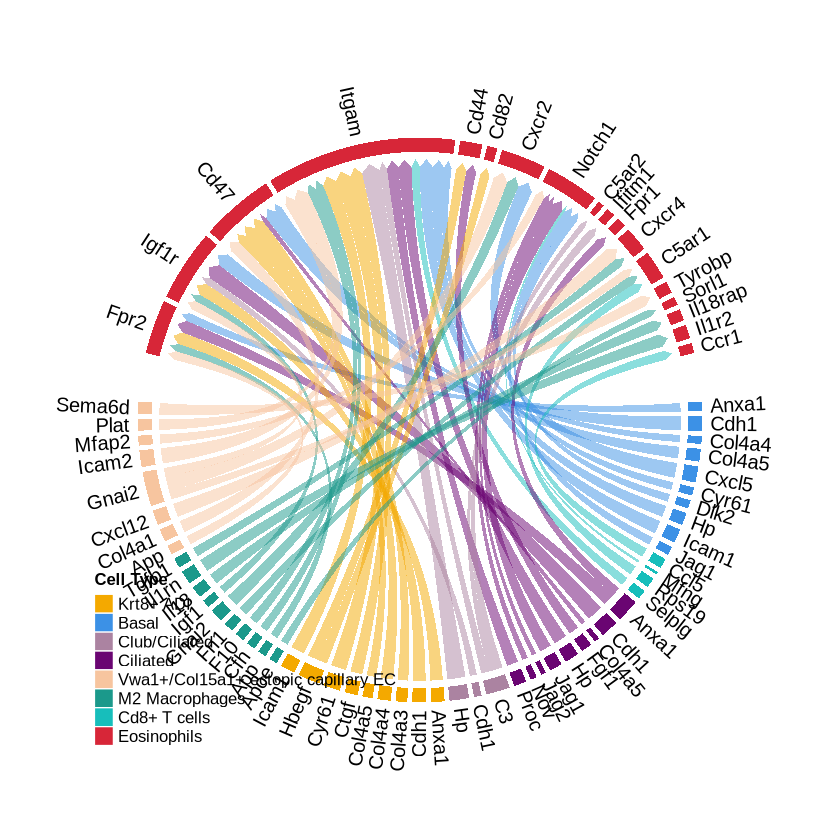

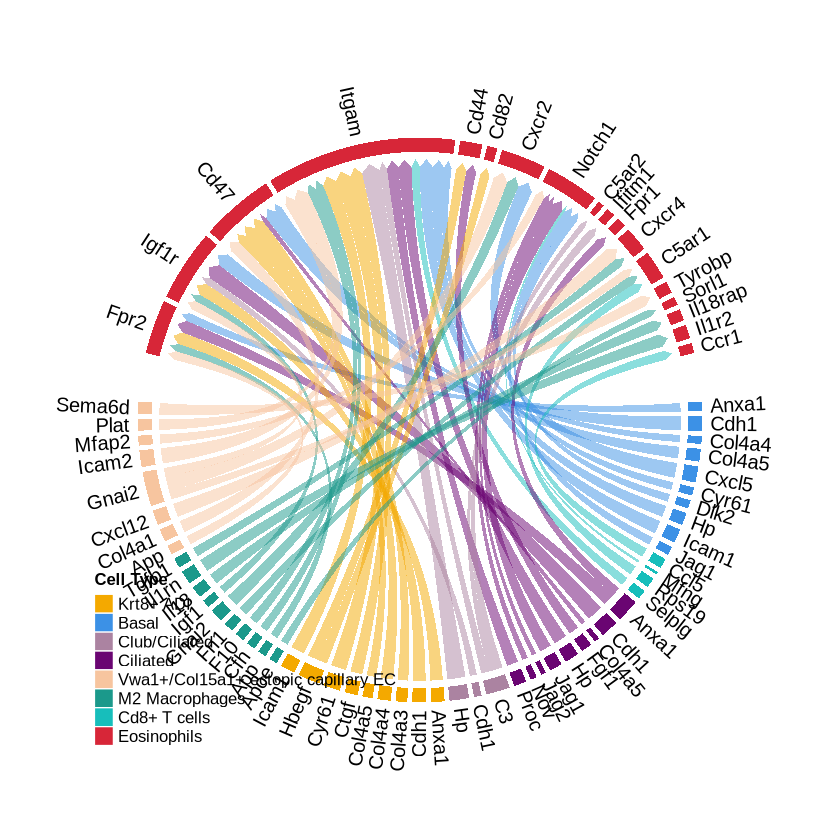

In [21]:
## niche-wise circos plot
CircosPlot(test,
           targets.include = 'Eosinophils',
           sources.include = reef_niche,
           cols.use = reef_colors,
           lab.cex = 1
                  )
circos_TO_eos <- recordPlot()

In [22]:
pdf('circos_plot_REEF_niche_TO_eosinophils.pdf', width = 10, height = 10)
replayPlot(circos_TO_eos)
dev.off()

pdf 
  2


Pre-filter edges:  578


Post-filter edges:  54


Connectome filtration completed

Warning message:
“Since you have set `order`, you should better set `grid.col` as a named
vector where sector names are the vector names, or else the color will
be wrongly assigned.”


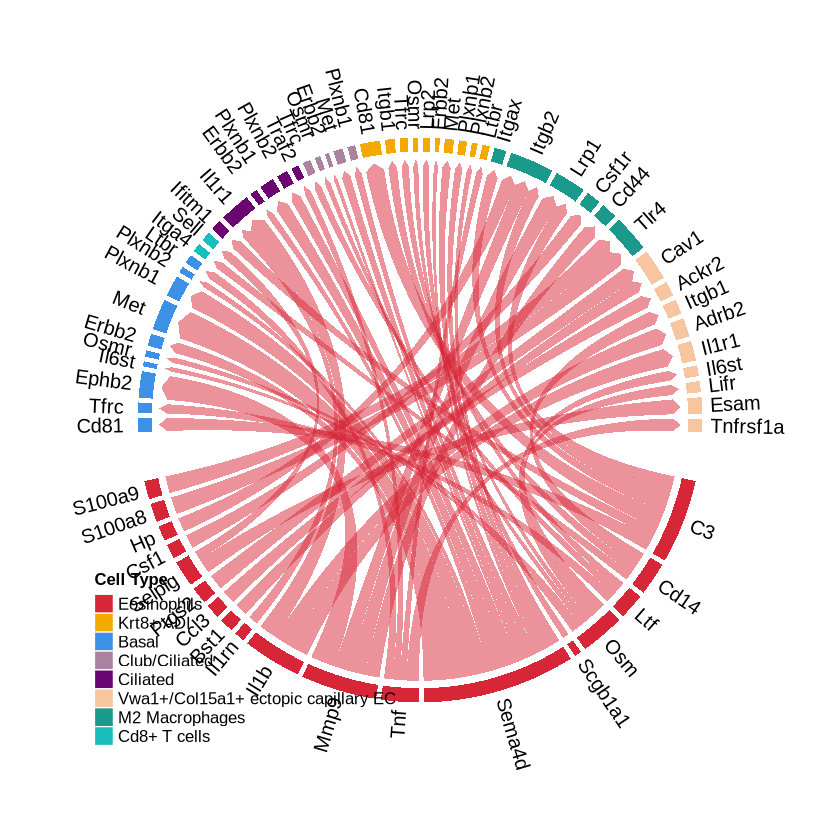

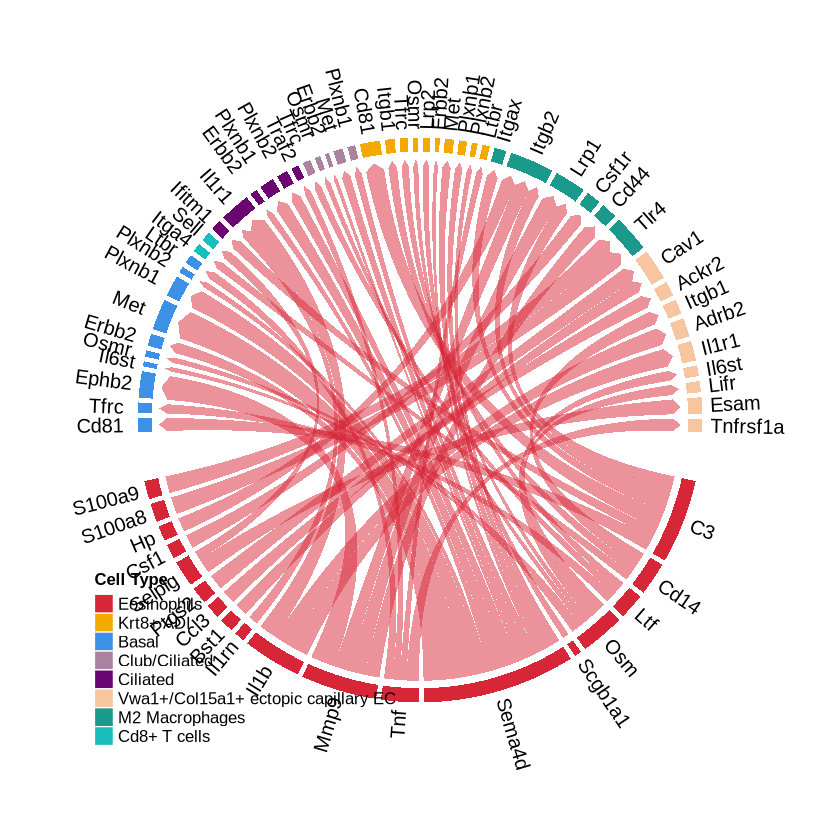

In [23]:
## source-wise circos plot
CircosPlot(test,
           targets.include = reef_niche,
           sources.include = 'Eosinophils',
           cols.use = reef_colors,
           lab.cex = 1
          )
circos_FROM_eos <- recordPlot()

In [24]:
pdf('circos_plot_REEF_niche_FROM_eosinophils.pdf', width = 10, height = 10)
replayPlot(circos_FROM_eos)
dev.off()

pdf 
  2